In [ ]:
# HAR-RV Forecasting Benchmark

This notebook implements the HAR-RV model used as the benchmark throughout the thesis.

The HAR-RV model forecasts one-day-ahead log-realized volatility using daily, weekly and monthly volatility components derived from the Oxford-Man Realized Volatility Library.

The analysis is performed on six major equity indices:
- EURO STOXX 50
- FTSE 100
- S&P 500
- NASDAQ Composite
- Nikkei 225
- Hang Seng Index

Mounted at /content/drive


,Symbol,MSE_test,QLIKE_test,beta_daily,beta_weekly,beta_monthly
0,.HSI,0.062991,0.178848,0.189299,0.430458,0.341189
1,.IXIC,0.086514,0.207668,0.384264,0.384664,0.193676
2,.SPX,0.096830,0.237560,0.262684,0.512791,0.173211
3,.STOXX50E,0.118549,0.291631,0.266915,0.472399,0.206545
4,.FTSE,0.101948,0.313942,0.276563,0.473397,0.204019
5,.N225,0.100969,0.378605,0.357948,0.382687,0.200221


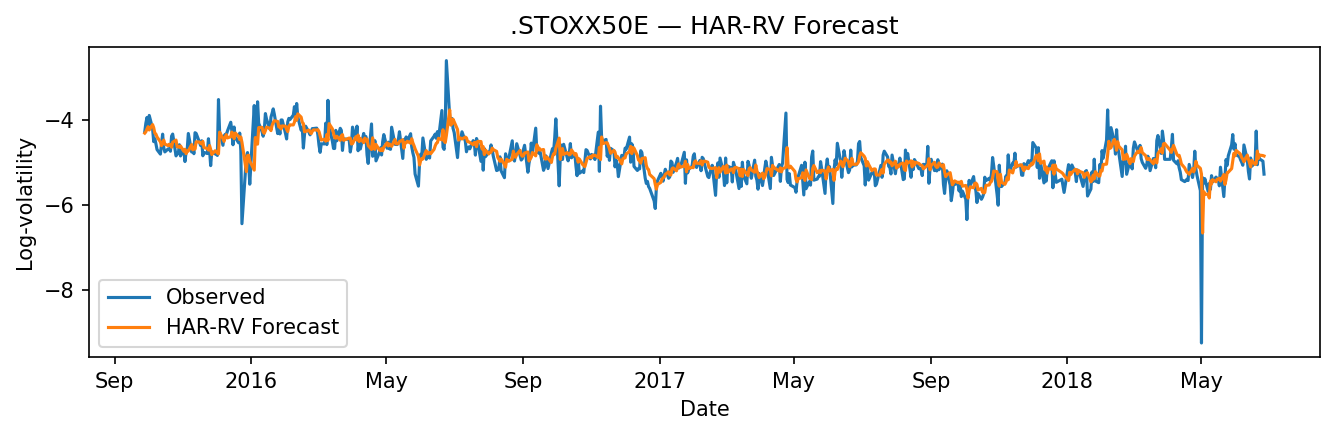

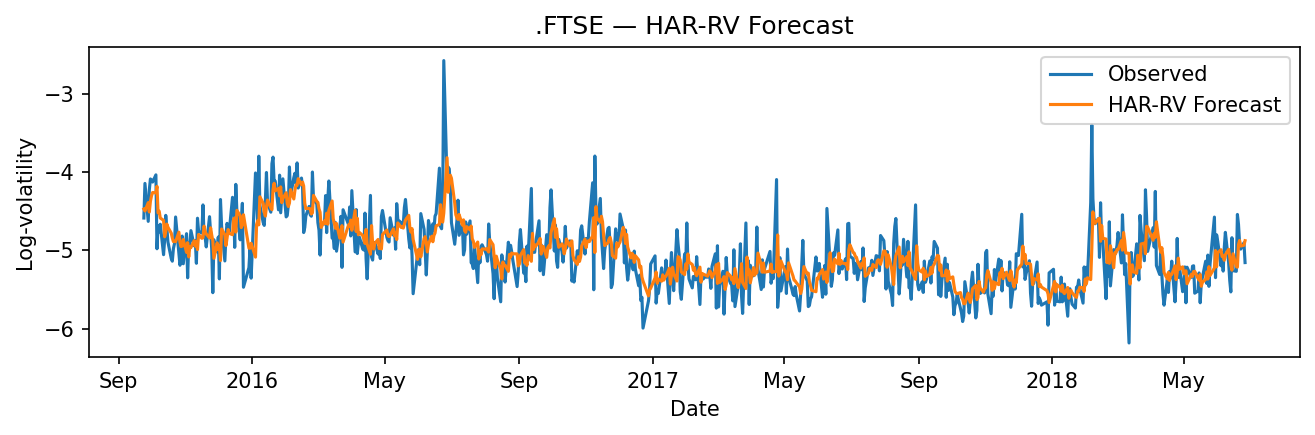

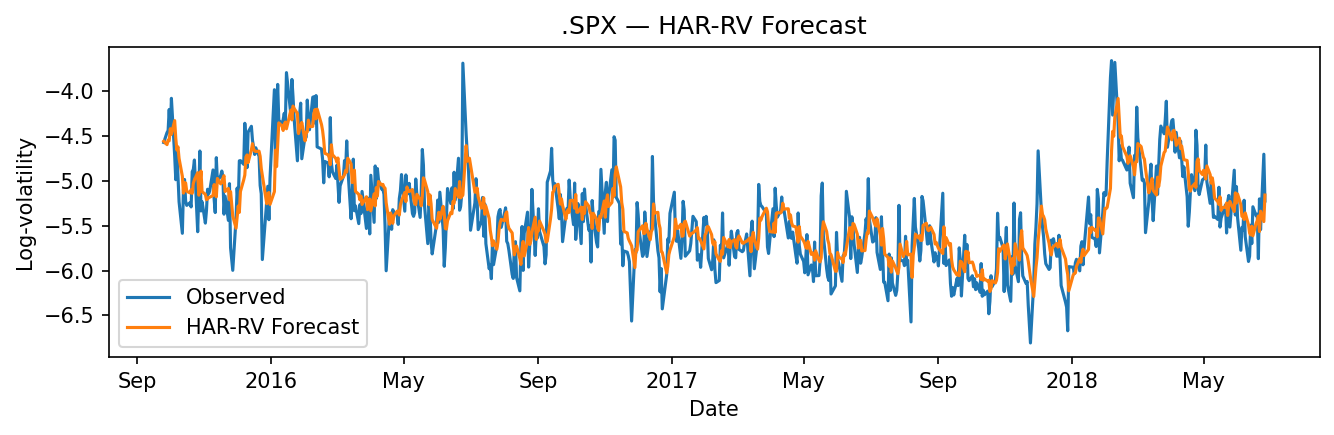

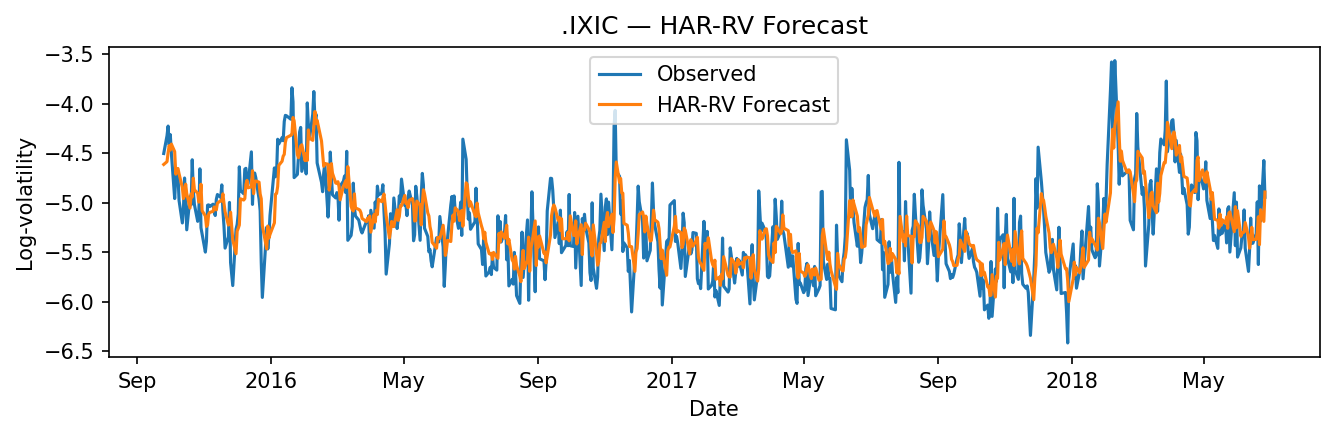

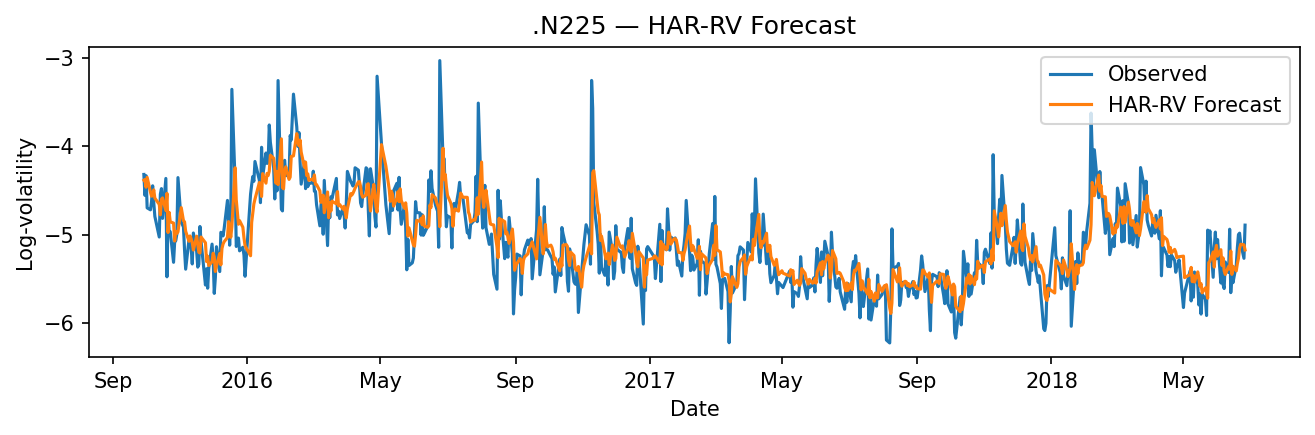

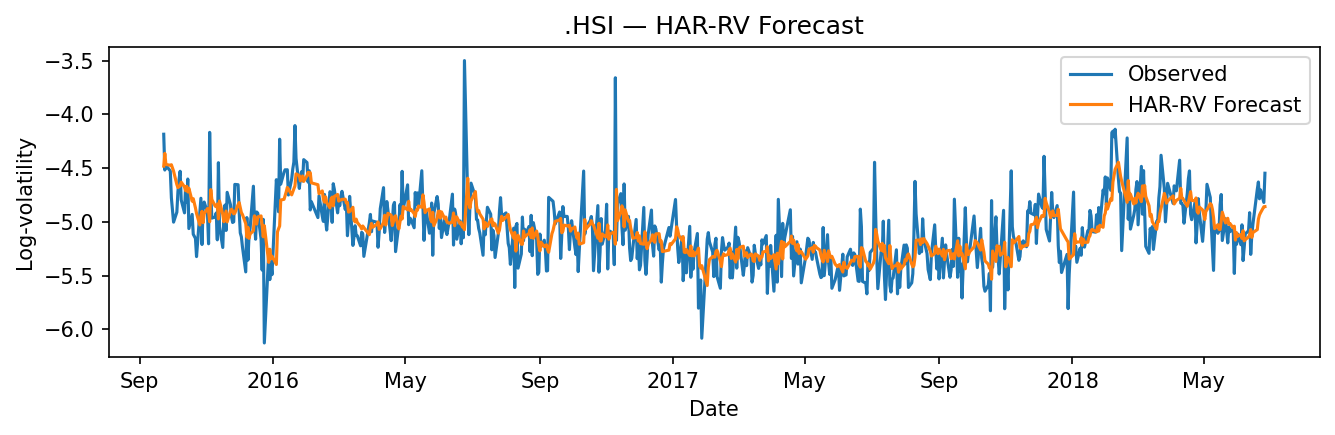


HAR-RV analysis completed successfully.


In [2]:
# ============================================================
# HAR-RV FORECASTING BENCHMARK
# Master's Thesis: From Fractional to Rough Volatility
# Author: Elisa Battista
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# Google Drive Setup
# ------------------------------------------------------------

MOUNTPOINT = "/content/drive"

if not os.path.isdir(f"{MOUNTPOINT}/MyDrive"):
    drive.mount(MOUNTPOINT)

BASE = f"{MOUNTPOINT}/MyDrive/thesis"
DATA_PATH = f"{MOUNTPOINT}/MyDrive/realvar.xlsx"

CLEAN_DIR = f"{BASE}/data/clean"
SPLIT_DIR = f"{BASE}/data/splits"
RESULTS_DIR = f"{BASE}/results/metrics"
PRED_DIR = f"{BASE}/results/preds"
FIG_DIR = f"{BASE}/results/figures"

for folder in [BASE, CLEAN_DIR, SPLIT_DIR, RESULTS_DIR, PRED_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------------------
# Load Oxford-Man Dataset
# ------------------------------------------------------------

df = pd.read_excel(DATA_PATH)

selected_indices = [
    ".STOXX50E",
    ".FTSE",
    ".SPX",
    ".IXIC",
    ".N225",
    ".HSI"
]

df = df[df["Symbol"].isin(selected_indices)].copy()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = (
    df.sort_values(["Symbol", "Date"])
      .drop_duplicates()
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# HAR-RV Feature Construction
# ------------------------------------------------------------

df["log_vol"] = 0.5 * np.log(df["rv5_ss"])

grp = df.groupby("Symbol")["log_vol"]

df["log_vol_d"] = grp.shift(0)

df["log_vol_w"] = (
    grp.rolling(5)
       .mean()
       .reset_index(level=0, drop=True)
)

df["log_vol_m"] = (
    grp.rolling(22)
       .mean()
       .reset_index(level=0, drop=True)
)

df["target"] = grp.shift(-1)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# Save Clean Datasets
# ------------------------------------------------------------

for symbol in selected_indices:

    df_i = df[df["Symbol"] == symbol].copy()

    clean_path = f"{CLEAN_DIR}/data_clean_{symbol}.csv"
    df_i.to_csv(clean_path, index=False)

# ------------------------------------------------------------
# Utility Functions
# ------------------------------------------------------------

FEATURES = ["log_vol_d", "log_vol_w", "log_vol_m"]
TARGET = "target"

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

def time_split(data):

    n = len(data)

    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    train = data.iloc[:n_train]
    val = data.iloc[n_train:n_train+n_val]
    test = data.iloc[n_train+n_val:]

    return train, val, test

def qlike(y_true_log, y_pred_log):

    var_true = np.exp(2 * y_true_log)
    var_pred = np.exp(2 * y_pred_log)

    return np.mean(
        var_true / var_pred
        - np.log(var_true / var_pred)
        - 1
    )

# ------------------------------------------------------------
# HAR-RV Estimation
# ------------------------------------------------------------

results = []

for symbol in selected_indices:

    df_i = df[df["Symbol"] == symbol].copy()

    df_i["Date_target"] = df_i["Date"].shift(-1)

    train, val, test = time_split(df_i)

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_val = val[FEATURES]
    y_val = val[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    mse_test = mean_squared_error(y_test, pred_test)
    qlike_test = qlike(y_test, pred_test)

    results.append({
        "Symbol": symbol,
        "MSE_test": mse_test,
        "QLIKE_test": qlike_test,
        "beta_daily": model.coef_[0],
        "beta_weekly": model.coef_[1],
        "beta_monthly": model.coef_[2]
    })

    pred_df = test[
        ["Symbol", "Date", "Date_target", TARGET]
    ].copy()

    pred_df.rename(
        columns={TARGET: "y_true"},
        inplace=True
    )

    pred_df["y_pred_HAR"] = pred_test

    pred_df.to_csv(
        f"{PRED_DIR}/pred_test_{symbol}.csv",
        index=False
    )

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

results_df = (
    pd.DataFrame(results)
      .sort_values("QLIKE_test")
      .reset_index(drop=True)
)

display(results_df)

results_df.to_csv(
    f"{RESULTS_DIR}/har_baseline_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# Forecast Plots
# ------------------------------------------------------------

for symbol in selected_indices:

    pred_path = f"{PRED_DIR}/pred_test_{symbol}.csv"

    pred_df = pd.read_csv(
        pred_path,
        parse_dates=["Date", "Date_target"]
    )

    plt.figure(figsize=(9,3), dpi=150)

    plt.plot(
        pred_df["Date_target"],
        pred_df["y_true"],
        label="Observed"
    )

    plt.plot(
        pred_df["Date_target"],
        pred_df["y_pred_HAR"],
        label="HAR-RV Forecast"
    )

    plt.title(f"{symbol} — HAR-RV Forecast")
    plt.xlabel("Date")
    plt.ylabel("Log-volatility")

    ax = plt.gca()

    ax.xaxis.set_major_locator(
        mdates.AutoDateLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(
            ax.xaxis.get_major_locator()
        )
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"{FIG_DIR}/har_forecast_{symbol.replace('.','')}.png",
        bbox_inches="tight"
    )

    plt.show()

print("\nHAR-RV analysis completed successfully.")